In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


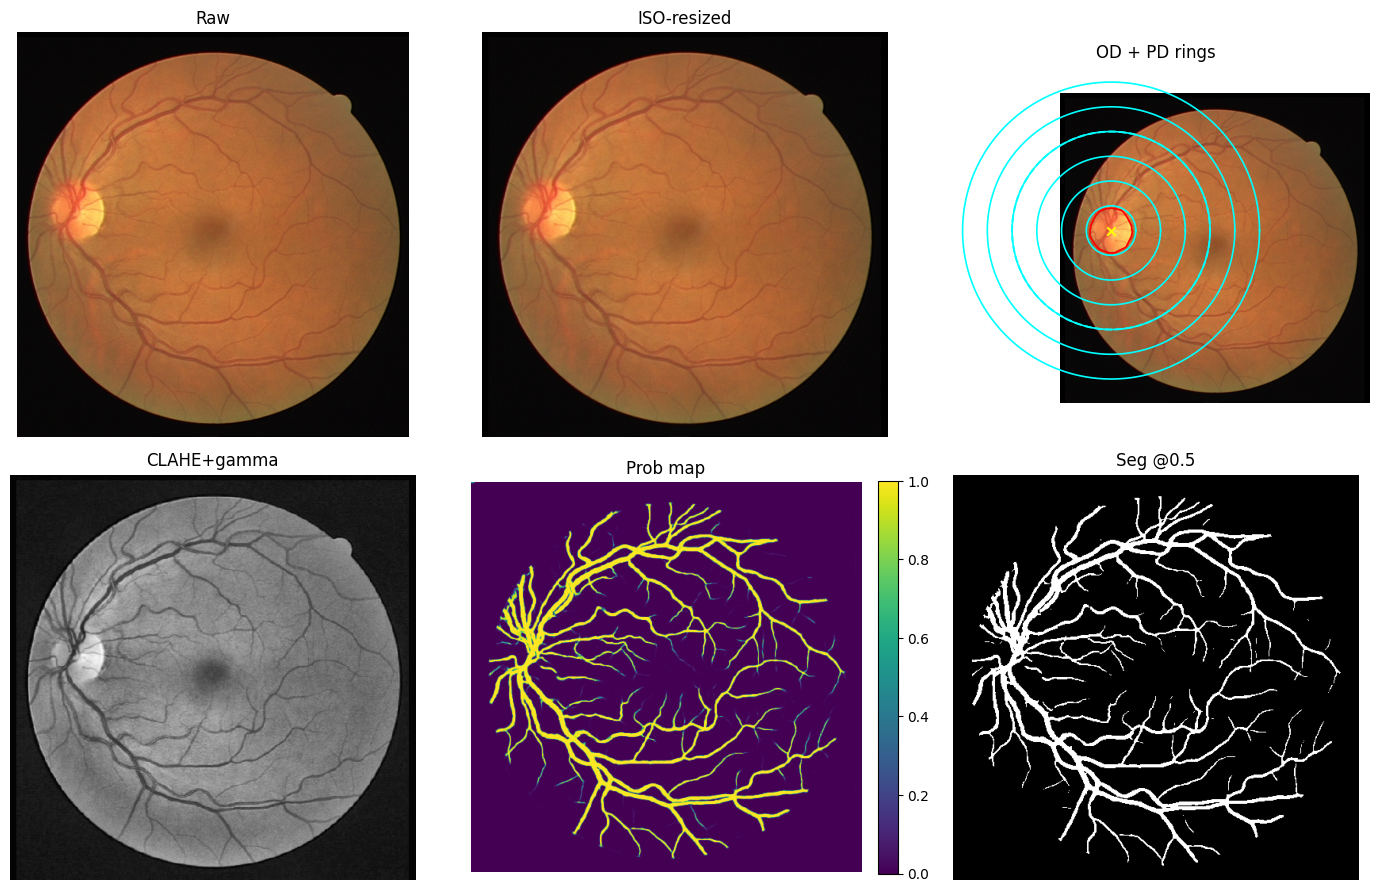

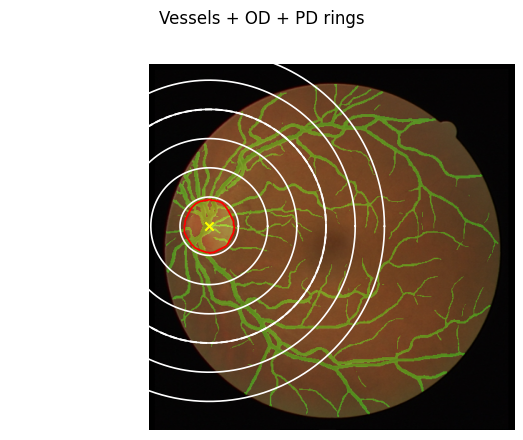

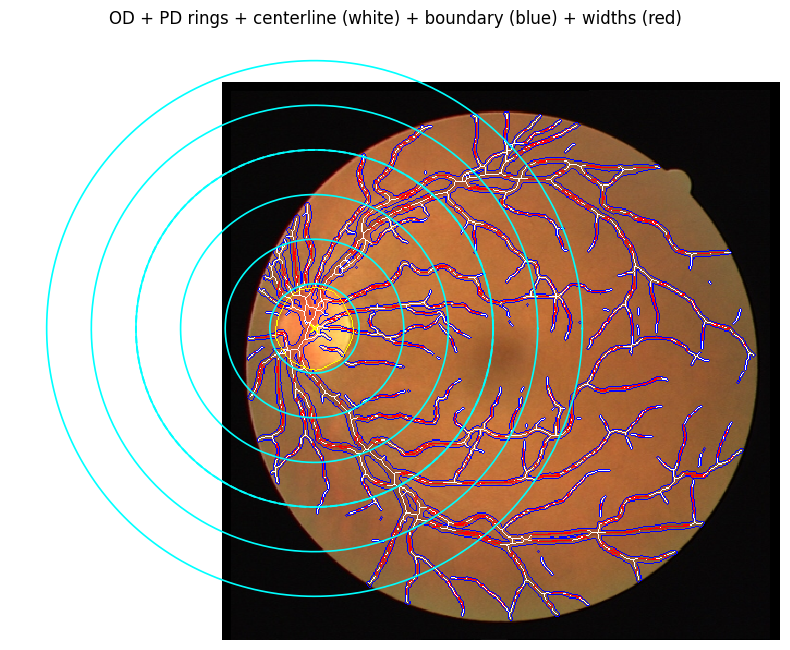

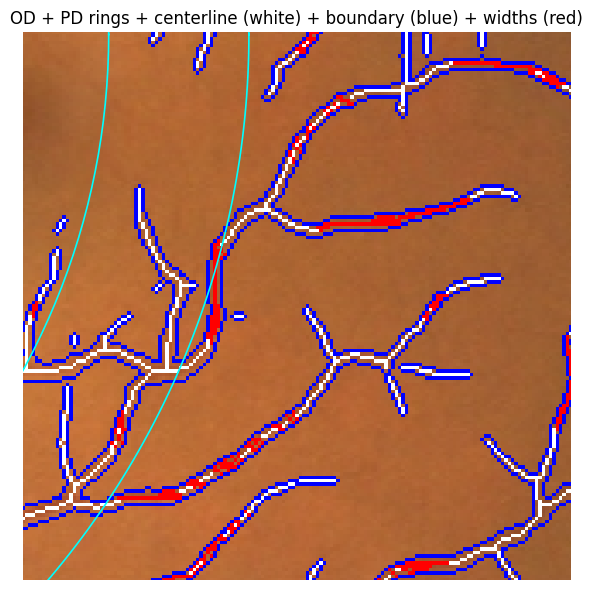

Metric,Value
Area density,0.101986
Length density (px^-1),0.032905
Fractal dimension,1.521231
Tortuosity (px^-2),0.185619
"Median width (px, orth)",4.500
"IQR width (px, orth)",3.500
Median width / PD,0.054932
IQR width / PD,0.042725
Length density · PD^2,220.820175


Topology,Value
Junctions,558
Endpoints,198
Junction density,0.002129
Endpoint density,0.000755
Angle p10,45.000
Angle p50,123.690
Angle p90,180.000
Angles ≤2PD: mean,110.463
Angles ≤2PD: std,48.274


Ring,Area dens,Len dens,FracDim,Median W,IQR W,Tortuosity ×10⁻³
0.0-0.5PD,0.393738,0.115696,1.046137,5.000,5.500,941932.700
0.5-1.0PD,0.221239,0.061808,1.163155,5.000,2.000,1221376.100
1.0-1.5PD,0.145367,0.045258,1.141145,4.000,3.000,1315230.900
1.5-2.0PD,0.106059,0.032339,1.118694,4.000,3.000,1462759.700
2.0-2.5PD,0.101095,0.031401,1.076988,5.000,3.000,1244519.800
2.5-3.0PD,0.101048,0.034571,1.121327,4.000,2.000,1269556.100


In [2]:
from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.notebook_utils.pipeline.retina import run_pipeline
from src.retina_biomarkers.notebook_utils.viz.overlays import visualize_grid, visualize_overlay, visualize_widths_centerline_boundary

# (1) INPUTS
ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DRIVE/test/images/01_test.png"
fov_path   = None  # or path to an external FOV mask if you have one

cfg = PipelineConfig(image_size=512, threshold=0.5, use_fov_in_model=False)

# (2) RUN
out = run_pipeline(color_path, ckpt_path, fov_path=fov_path, cfg=cfg)

# (3) VISUALS
visualize_grid(out)
visualize_overlay(out)

# (4) METRIC TABLES
import pandas as pd
from IPython.display import display, HTML

bio = out["biomarkers"]; g = bio["global"]; t = bio["topology"]; rings = bio.get("rings") or {}

global_rows = [
    ("Area density",                 f"{g['area_density']:.6f}"),
    ("Length density (px^-1)",       f"{g['length_density_px_inv']:.6f}"),
    ("Fractal dimension",            f"{g['fractal_dimension']:.6f}"),
    ("Tortuosity (px^-2)",           f"{g['tortuosity_mean']:.6f}"),
    #("Tortuosity ×10⁻³ (per PD²)",  f"{g.get('tortuosity_mean_PD2_x1e3', float('nan')):.3f}"),
    ("Median width (px, orth)",      f"{g['vc_orth']['median_width']:.3f}"),
    ("IQR width (px, orth)",         f"{g['vc_orth']['iqr_width']:.3f}"),
    ("Median width / PD",            f"{g.get('median_width_PD', float('nan')):.6f}"),
    ("IQR width / PD",               f"{g.get('iqr_width_PD',    float('nan')):.6f}"),
    ("Length density · PD^2",        f"{g.get('length_density_PD_inv', float('nan')):.6f}"),
]
df_global = pd.DataFrame(global_rows, columns=["Metric", "Value"])

topo_rows = [
    ("Junctions",          int(t.get("junction_count", 0))),
    ("Endpoints",          int(t.get("endpoint_count", 0))),
    ("Junction density",   f"{t.get('junction_density', 0.0):.6f}"),
    ("Endpoint density",   f"{t.get('endpoint_density', 0.0):.6f}"),
    ("Angle p10",          f"{t.get('angle_p10', 0.0):.3f}"),
    ("Angle p50",          f"{t.get('angle_p50', 0.0):.3f}"),
    ("Angle p90",          f"{t.get('angle_p90', 0.0):.3f}"),
]
if isinstance(t.get("angles_2PD"), dict):
    a2 = t["angles_2PD"]
    topo_rows += [("Angles ≤2PD: mean", f"{a2.get('angle_mean', 0.0):.3f}"),
                  ("Angles ≤2PD: std",  f"{a2.get('angle_std', 0.0):.3f}")]
df_topo = pd.DataFrame(topo_rows, columns=["Topology", "Value"])

ring_rows = []
for ring_name, r in rings.items():
    ring_rows.append([
        ring_name,
        f"{r.get('area_density', 0.0):.6f}",
        f"{r.get('length_density', 0.0):.6f}",
        f"{r.get('fractal_dimension', 0.0):.6f}",
        f"{r.get('median_width', 0.0):.3f}",
        f"{r.get('iqr_width', 0.0):.3f}",
        f"{r.get('tortuosity_mean_PD2_x1e3', 0.0):.3f}",
    ])
df_rings = pd.DataFrame(ring_rows, columns=["Ring","Area dens","Len dens","FracDim","Median W","IQR W","Tortuosity ×10⁻³"])


# full-frame view
_ = visualize_widths_centerline_boundary(
    out,
    # chord sampling knobs 
    stride_by_arc=2.0,
    margin_from_nodes=7.0,
    step=0.25,
    max_radius=20.0,
    clip_k_edt=1.25,
    min_len=0.75,
    tan_win_px=11,
    use_pca=True,
    pca_radius_px=7,
    kappa_max=0.18,
    asym_max_ratio=1.6,
    # drawing knobs:
    chord_lw=1.5, center_lw=1.0, boundary_lw=1.0,
    ring_color="cyan",
    figsize=(8, 8),
)

# zoomed close-up (use OD center as reference if you like)
zoom_center = (int(out["od"]["center_yx"][0] + 80), int(out["od"]["center_yx"][1] + 260))
_ = visualize_widths_centerline_boundary(
    out,
    zoom=(zoom_center[0], zoom_center[1], 80),   # (cy, cx, radius_px)
    figsize=(6, 6),
)


display(HTML("<h3>Global Metrics</h3>")); display(df_global.style.hide(axis='index'))
display(HTML("<h3>Topology Metrics</h3>")); display(df_topo.style.hide(axis='index'))
display(HTML("<h3>Ring-wise Metrics</h3>")); display(df_rings.style.hide(axis='index'))




In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------- 1) FLATTENER (global + rings; tortuosity in px^-2) ----------
def flatten_metrics_v3(out, um_per_px=None):
    """
    Returns a flat dict for tables/plots.
    Uses tortuosity in px^-2 (no PD normalization).
    Adds ring-wise fractal dimension, density, tortuosity, caliber.
    """
    bio = out["biomarkers"]
    g   = bio["global"]
    t   = bio["topology"]
    rings = bio.get("rings") or {}

    # GLOBALS
    area_density_pct = 100.0 * float(g["area_density"])          # %
    tort_px2 = float(g["tortuosity_mean"])                        # px^-2
    fracdim  = float(g["fractal_dimension"])                      # unitless

    # branching angle (not plotted below, but kept in case you need it)
    if isinstance(t.get("angles_2PD"), dict) and "angle_mean" in t["angles_2PD"]:
        angle_deg = float(t["angles_2PD"]["angle_mean"])
    else:
        angle_deg = float(t.get("angle_mean", np.nan))

    # "caliber" = median orth width; convert to µm if scale given
    median_w_px = float(g["vc_orth"]["median_width"])
    iqr_w_px    = float(g["vc_orth"]["iqr_width"])
    if um_per_px is not None:
        caliber = median_w_px * um_per_px
        caliber_field = "caliber_um"
    else:
        caliber = median_w_px
        caliber_field = "caliber_px"

    row = {
        "fractal_dimension": fracdim,
        "area_density_pct":  area_density_pct,
        "tortuosity_px2":    tort_px2,
        caliber_field:       caliber,
        # extra globals for the table
        "median_width_px":   median_w_px,
        "iqr_width_px":      iqr_w_px,
        "angle_mean_deg":    angle_deg,
    }

    # RINGS (use 0.5–2.5 PD like the paper figure)
    wanted_starts = [0.5, 1.0, 1.5, 2.0]
    for k, r in rings.items():
        try:
            r0 = float(k.split("-")[0])
        except:
            continue
        if r0 not in wanted_starts:
            continue

        # ring metrics
        row[f"{k}|fractal_dimension"]  = float(r.get("fractal_dimension", np.nan))
        row[f"{k}|area_density_pct"]   = 100.0 * float(r.get("area_density", np.nan))
        row[f"{k}|tortuosity_px2"]     = float(r.get("tortuosity_mean", np.nan))  # px^-2

        r_med_w_px = float(r.get("median_width", np.nan))
        if um_per_px is not None:
            row[f"{k}|caliber"] = r_med_w_px * um_per_px
            row[f"{k}|caliber_unit"] = "µm"
        else:
            row[f"{k}|caliber"] = r_med_w_px
            row[f"{k}|caliber_unit"] = "px"

    return row

# ---------- 2) SUMMARY TABLE (adds Median/IQR width in px) ----------
def make_summary_table_v3(dfN, dfD, um_scale_available=True):
    """
    Columns:
      Retinal vascular parameters | Normal Mean (±SD) | DR Mean (±SD)
    Includes Median/IQR width (px) in the global table.
    """
    cal_key   = "caliber_um" if um_scale_available and "caliber_um" in dfN.columns else "caliber_px"
    cal_label = "Vascular caliber (µm)" if cal_key == "caliber_um" else "Vascular caliber (px)"

    rows = [
        ("Vascular fractal dimension",   "fractal_dimension"),
        ("Vascular density (%)",         "area_density_pct"),
        ("Vascular tortuosity (px⁻²)",   "tortuosity_px2"),
        (cal_label,                       cal_key),
        ("Median width (px, orth)",      "median_width_px"),
        ("IQR width (px, orth)",         "iqr_width_px"),
    ]

    def _fmt(mean, sd):
        return "—" if np.isnan(mean) else f"{mean:.3f} \u00B1 {sd:.3f}"

    table = []
    for label, key in rows:
        Nm, Ns = dfN[key].mean(), dfN[key].std()
        Dm, Ds = dfD[key].mean(), dfD[key].std()
        table.append([label, _fmt(Nm, Ns), _fmt(Dm, Ds)])

    return pd.DataFrame(table, columns=["Retinal vascular parameters", "Normal Mean (±SD)", "DR Mean (±SD)"])

# ---------- 3) GLOBAL BAR COMPARISON (4 metrics only) ----------
def bar_global_v3(dfN, dfD, keys, label_map, title):
    meansN, sdsN = dfN[keys].mean(), dfN[keys].std()
    meansD, sdsD = dfD[keys].mean(), dfD[keys].std()

    x = np.arange(len(keys)).astype(float)
    w = 0.28   # thinner bars
    # space groups a bit
    x = x * 1.4

    plt.figure(figsize=(12, 4.2))
    plt.bar(x - w/2, meansN.values, yerr=sdsN.values, capsize=3, width=w, label="Normal")
    plt.bar(x + w/2, meansD.values, yerr=sdsD.values, capsize=3, width=w, label="DR")
    plt.xticks(x, [label_map[k] for k in keys], rotation=15, ha="right")
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

# ---------- 4) RING-WISE BAR CHARTS (thinner bars + gaps) ----------
def _ring_columns(df, suffix):
    cols = [c for c in df.columns if c.endswith("|"+suffix)]
    keyed = []
    for c in cols:
        try:
            r0 = float(c.split("|")[0].split("-")[0])
            keyed.append((r0, c))
        except:
            pass
    return [c for _, c in sorted(keyed)]  # ordered by ring start

def bar_rings_v3(
    dfN, dfD, suffix, title, ylabel,
    bar_width=0.28,          # <- thinner/thicker bars
    group_gap=1,           # <- multiply spacing between ring groups
    ylims=None,              # <- (ymin, ymax) to zoom Y
    ypad_frac=0.05
):
    """
    suffix ∈ {'fractal_dimension','area_density_pct','tortuosity_px2','caliber',
              'median_width_px','iqr_width_px'}
    """
    import numpy as np
    import matplotlib.pyplot as plt

    def _ring_columns(df, suffix):
        cols = [c for c in df.columns if c.endswith("|"+suffix)]
        keyed = []
        for c in cols:
            try:
                r0 = float(c.split("|")[0].split("-")[0])
                keyed.append((r0, c))
            except:
                pass
        return [c for _, c in sorted(keyed)]

    colsN = _ring_columns(dfN, suffix)
    colsD = _ring_columns(dfD, suffix)
    cols  = [c for c in colsN if c in colsD]
    if not cols:
        print(f"[warn] no ring columns found for '{suffix}'"); 
        return

    ring_labels = [c.split("|")[0].replace("PD"," PD") for c in cols]
    mN, sN = dfN[cols].mean().values, dfN[cols].std().values
    mD, sD = dfD[cols].mean().values, dfD[cols].std().values

    # positions: widen gaps between each ring group
    base = np.arange(len(cols)).astype(float) * group_gap

    plt.figure(figsize=(10, 4.2))
    plt.bar(base - bar_width/2, mN, yerr=sN, capsize=3, width=bar_width, label="Normal")
    plt.bar(base + bar_width/2, mD, yerr=sD, capsize=3, width=bar_width, label="DR")
    plt.xticks(base, ring_labels)
    plt.ylabel(ylabel); plt.title(title)
    plt.legend(); plt.grid(axis="y", alpha=0.2)

    # Y zoom
    if ylims is not None:
        plt.ylim(*ylims)
    else:
        lo = float(np.nanmin([mN - (sN or 0), mD - (sD or 0)]))
        hi = float(np.nanmax([mN + (sN or 0), mD + (sD or 0)]))
        pad = (hi - lo) * ypad_frac if hi > lo else 1.0
        plt.ylim(lo - pad, hi + pad)

    plt.tight_layout(); plt.show()

def bar_global_panels(dfN, dfD, keys, titles_map, ylabels_map,
                      figsize=(12, 3.4), bar_width=0.24):
    """
    Draw small-multiple bar charts: one subplot per global biomarker.
    Each subplot shows Normal vs DR (mean ± SD).
    """
    import numpy as np
    import matplotlib.pyplot as plt

    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # consistent x positions for Normal vs DR
    x = np.array([0, 1])

    for ax, key in zip(axes, keys):
        mN, sN = dfN[key].mean(), dfN[key].std()
        mD, sD = dfD[key].mean(), dfD[key].std()

        ax.bar(x[0], mN, yerr=sN, capsize=3, width=bar_width, label="Normal")
        ax.bar(x[1], mD, yerr=sD, capsize=3, width=bar_width, label="DR")

        ax.set_xticks(x); ax.set_xticklabels(["Normal", "DR"])
        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.tick_params(axis="x", labelrotation=0)
        ax.grid(axis="y", alpha=0.2)

    # single shared legend (top-right)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", frameon=False)
    return fig, axes



# ---------- GLOBAL (4 metrics), each in its own small panel ----------
def bar_global_panels(
    dfN, dfD, keys, titles_map, ylabels_map,
    figsize=(12, 4),
    bar_width=0.24,
    pair_sep=0.60,
    panel_wspace=0.02,
    ylims=None,
    ypad_frac=0.05,
    # NEW:
    legend_top=True,
    legend_ncols=2,
    top_pad_frac=0.15   # fraction of figure height to reserve at the top
):
    import numpy as np
    import matplotlib.pyplot as plt

    if bar_width >= pair_sep:
        bar_width = max(0.01, pair_sep * 0.45)

    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, constrained_layout=True)
    if n == 1:
        axes = [axes]

    # tighten inter-panel spacing + reserve top margin
    try:
        # h_pad is in inches; estimate from figure height
        h_in = figsize[1]
        fig.set_constrained_layout_pads(
            wspace=panel_wspace,
            hspace=0.02,
            h_pad=h_in * top_pad_frac
        )
    except Exception:
        # fallback if constrained_layout pads unavailable
        fig.subplots_adjust(top=1.0 - top_pad_frac, wspace=panel_wspace)

    x = np.array([-pair_sep/2.0, pair_sep/2.0])  # [Normal, DR] centers

    for ax, key in zip(axes, keys):
        mN, sN = dfN[key].mean(), dfN[key].std()
        mD, sD = dfD[key].mean(), dfD[key].std()

        ax.bar(x[0], mN, yerr=sN, capsize=3, width=bar_width, label="Normal")
        ax.bar(x[1], mD, yerr=sD, capsize=3, width=bar_width, label="DR")

        ax.set_xticks(x); ax.set_xticklabels(["Normal", "DR"])
        ax.set_title(titles_map.get(key, key), fontsize=10)
        ax.set_ylabel(ylabels_map.get(key, "Value"))
        ax.grid(axis="y", alpha=0.2)
        ax.set_xlim(-pair_sep, pair_sep)

        # y-zoom / auto
        if isinstance(ylims, dict) and key in ylims and ylims[key] is not None:
            ax.set_ylim(*ylims[key])
        else:
            lo = float(min(mN - (sN or 0), mD - (sD or 0)))
            hi = float(max(mN + (sN or 0), mD + (sD or 0)))
            pad = (hi - lo) * ypad_frac if hi > lo else 1.0
            ax.set_ylim(lo - pad, hi + pad)

    # move legend to top center, outside plots
    handles, labels = axes[-1].get_legend_handles_labels()
    if legend_top:
        fig.legend(handles, labels, loc="upper center",
                   bbox_to_anchor=(0.5, 1.0), ncol=legend_ncols, frameon=False)
    else:
        fig.legend(handles, labels, loc="upper right", frameon=False)

    return fig, axes



In [33]:
from src.retina_biomarkers.notebook_utils.pipeline.config import PipelineConfig
from src.retina_biomarkers.notebook_utils.pipeline.retina import run_pipeline
from src.retina_biomarkers.notebook_utils.report.compare import (
    draw_overlay_ax,         # overlay helper
    # flatten_metrics_v3,      # your flattener
    # make_summary_table_v3,   # summary table (adds median/IQR width)
    # bar_global_panels,       # small-multiple global bars
    # bar_rings_v3,            # ring-wise bars with spacing
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cfg = PipelineConfig()
ckpt_path = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"

normal_paths = [
    "../../data/raw/DRIVE/test/images/12_test.png",
    "../../data/raw/DRIVE/test/images/10_test.png",
    "../../data/raw/DRIVE/test/images/13_test.png",
]
dr_paths = [
    "../../data/raw/DRIVE/test/images/03_test.png",
    "../../data/raw/DRIVE/test/images/08_test.png",
    "../../data/raw/DRIVE/test/images/17_test.png",
]

def run_list(paths):
    outs = []
    for p in paths:
        try:
            outs.append(run_pipeline(p, ckpt_path, cfg=cfg))
        except Exception as e:
            print(f"[warn] failed on {p}: {e}")
    return outs

# 1) RUN FIRST
outs_norm = run_list(normal_paths)
outs_dr   = run_list(dr_paths)


d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


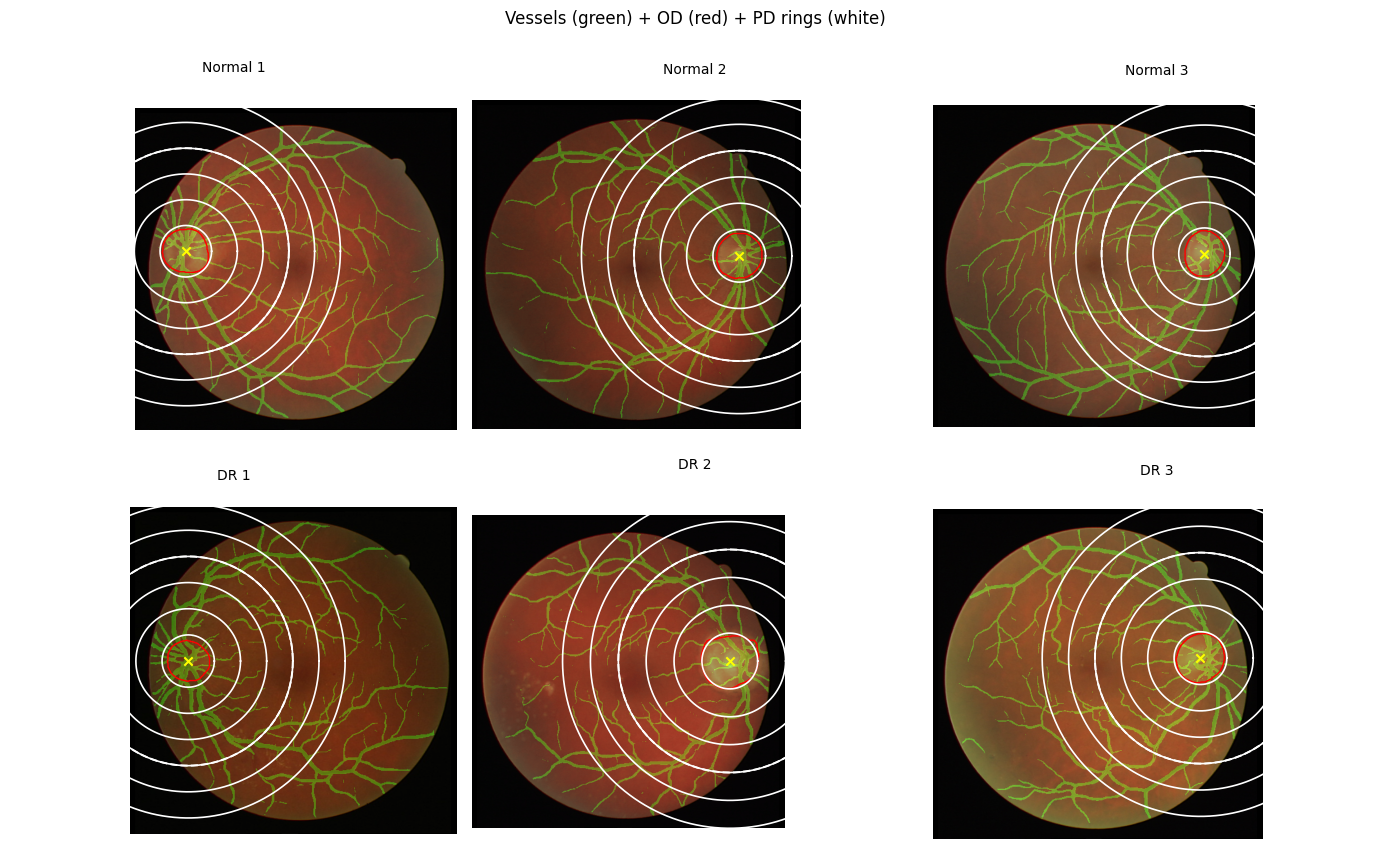

,Retinal vascular parameters,Normal Mean (±SD),DR Mean (±SD)
0,Vascular fractal dimension,1.492 ± 0.023,1.474 ± 0.012
1,Vascular density (%),8.738 ± 0.643,8.234 ± 0.724
2,Vascular tortuosity (px⁻²),0.184 ± 0.002,0.183 ± 0.006
3,Vascular caliber (px),4.333 ± 0.289,4.500 ± 0.500
4,"Median width (px, orth)",4.333 ± 0.289,4.500 ± 0.500
5,"IQR width (px, orth)",3.500 ± 0.000,3.667 ± 0.289


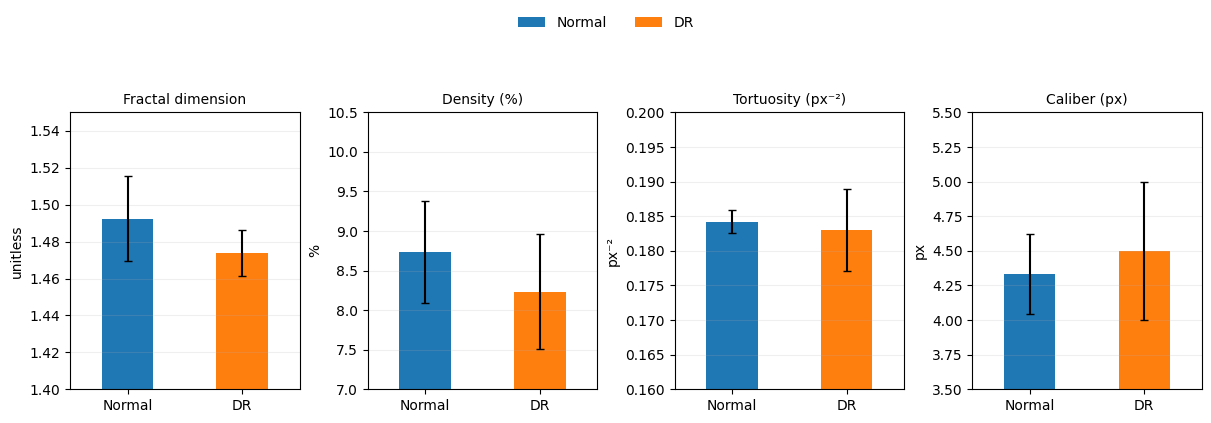

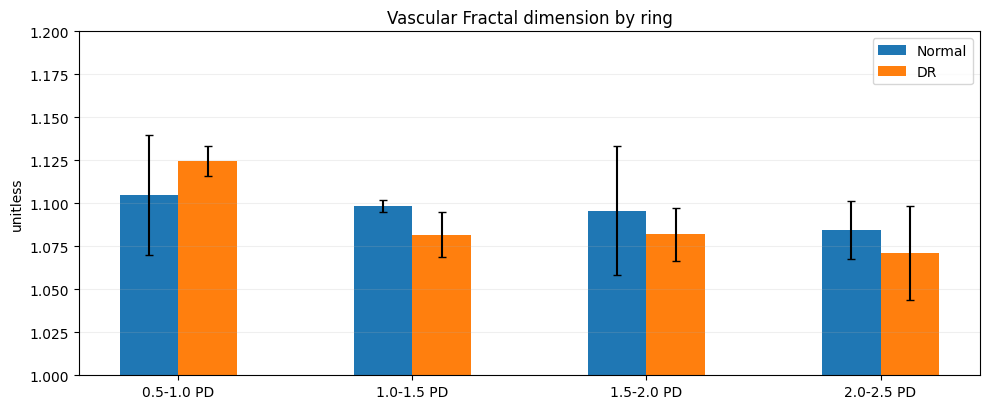

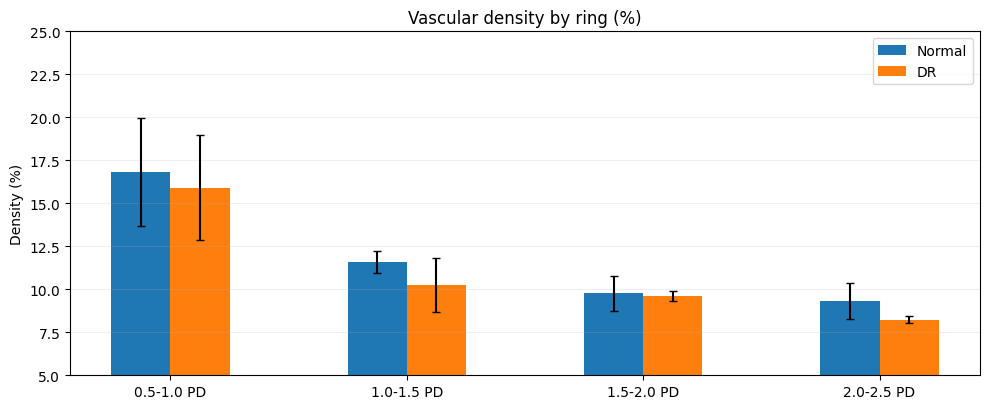

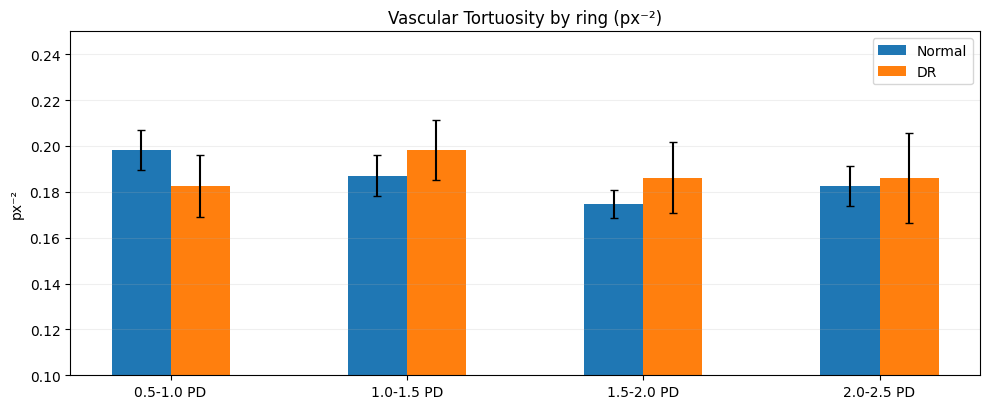

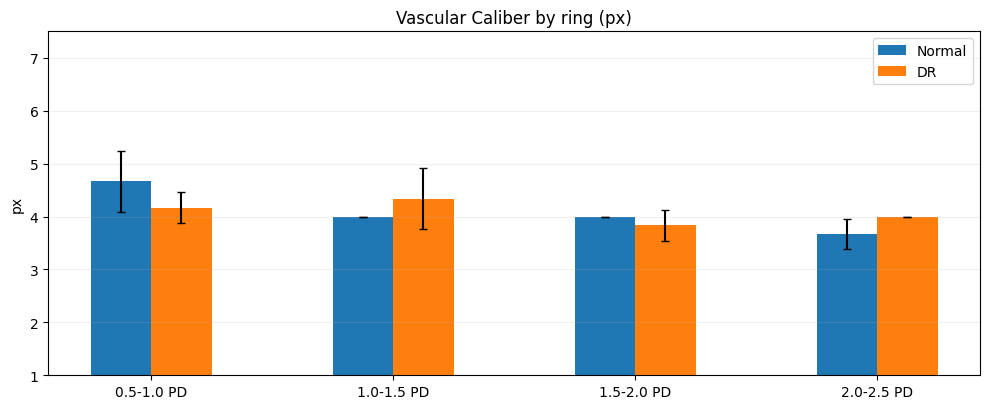

In [31]:
# 2) OVERLAYS (2×3)
fig, axs = plt.subplots(2, 3, figsize=(14, 9))
for i in range(3):
    if i < len(outs_norm):
        draw_overlay_ax(axs[0, i], outs_norm[i], f"Normal {i+1}")
    else:
        axs[0, i].axis("off")
    if i < len(outs_dr):
        draw_overlay_ax(axs[1, i], outs_dr[i],   f"DR {i+1}")
    else:
        axs[1, i].axis("off")
fig.suptitle("Vessels (green) + OD (red) + PD rings (white)", y=0.98)
plt.tight_layout(); plt.show()

# 3) FLATTEN → DATAFRAMES (set um_per_px if you have a real scale)
dfN = pd.DataFrame([flatten_metrics_v3(o, um_per_px=None) for o in outs_norm])
dfD = pd.DataFrame([flatten_metrics_v3(o, um_per_px=None) for o in outs_dr])

# 4) SUMMARY TABLE (includes Median/IQR width in px)
tbl = make_summary_table_v3(dfN, dfD, um_scale_available=("caliber_um" in dfN.columns))
from IPython.display import display
display(tbl)

# 5) GLOBAL BARS (small-multiples)
cal_key = "caliber_um" if "caliber_um" in dfN.columns else "caliber_px"
keys = ["fractal_dimension", "area_density_pct", "tortuosity_px2", cal_key]

titles_map = {
    "fractal_dimension": "Fractal dimension",
    "area_density_pct":  "Density (%)",
    "tortuosity_px2":    "Tortuosity (px⁻²)",
    cal_key:             "Caliber (µm)" if cal_key == "caliber_um" else "Caliber (px)",
}
ylabels_map = {
    "fractal_dimension": "unitless",
    "area_density_pct":  "%",
    "tortuosity_px2":    "px⁻²",
    cal_key:             ("µm" if cal_key == "caliber_um" else "px"),
}

# Tight y-limits per panel (EDIT these to your data range)
global_ylims = {
    "fractal_dimension": (1.40, 1.55),
    "area_density_pct":  (7.0, 10.5),
    "tortuosity_px2":    (0.16, 0.20),
    cal_key:             (3.5, 5.5)   # if px; or e.g. (80, 120) if µm
}

# Draw the 4 small panels with thinner bars
bar_global_panels(
    dfN, dfD, keys, titles_map, ylabels_map,
    figsize=(12, 5),
    bar_width=0.22,      # thinner bars
    pair_sep=0.15,       # closer together
    panel_wspace=0.008,  # tighter panels
    ylims=global_ylims,
    ypad_frac=0.03,
    legend_top=True, legend_ncols=2, top_pad_frac=0.18,
)

# Ring-wise bars (thinner + visible gaps) with custom y-zoom
bar_rings_v3(dfN, dfD, "fractal_dimension", "Vascular Fractal dimension by ring", "unitless",
             bar_width=0.25, group_gap=1.0, ylims=(1.00, 1.20))

bar_rings_v3(dfN, dfD, "area_density_pct",  "Vascular density by ring (%)", "Density (%)",
             bar_width=0.25, group_gap=1.0, ylims=(5.0, 25.0))

bar_rings_v3(dfN, dfD, "tortuosity_px2",    "Vascular Tortuosity by ring (px⁻²)",       "px⁻²",
             bar_width=0.25, group_gap=1.0, ylims=(0.10, 0.25))

unit = "µm" if "caliber_um" in dfN.columns else "px"
bar_rings_v3(dfN, dfD, "caliber",           f"Vascular Caliber by ring ({unit})",          unit,
             bar_width=0.25, group_gap=1.0, ylims=(1.0, 7.5))